In [45]:
import seaborn as sns
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt


In [46]:

pengu_df =sns.load_dataset('penguins')
label = 'bill_length_mm'
pengu_df = pengu_df.dropna(subset=[label])

In [47]:

y = pengu_df[label]
features = [i for i in pengu_df.columns if i!=label]
X = pengu_df[features]
X.head()


,species,island,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,20.6,190.0,3650.0,Male


In [48]:
num_cols = [i for i in X.columns if X[i].dtype in ['int64','float64'] and i!=label]
cate_cols = [i for i in X.columns if X[i].dtype=='object']


In [49]:
num_trans = SimpleImputer(strategy='mean')

cate_trans = Pipeline(
    steps=[
        ('impute',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore'))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ('num',num_trans,num_cols),
        ('categorical',cate_trans,cate_cols)
    ]
)

In [50]:
model = DecisionTreeRegressor(random_state=1)
my_pipeline = Pipeline(
    steps = [
        ('preprocessing',preprocessor),
        ('model',model)
    ]
)
mae = -1 * cross_val_score(my_pipeline,X,y,cv=5,scoring='neg_mean_absolute_error')
print(mae.mean())

2.3438235294117646


In [51]:
def score(x):
    model = DecisionTreeRegressor(max_leaf_nodes=x,random_state=1)
    my_pipeline2 = Pipeline(
    steps = [
        ('preprocessing',preprocessor),
        ('model',model)
    ]
)
    mae_hype = -1*cross_val_score(my_pipeline2,X,y,cv=5,scoring='neg_mean_absolute_error')
    return mae_hype.mean()
results = {}
for i in range(1,9):
    j = 50*i
    results[j]=score(j)
    print(f"For {j} nodes we get a mean absolute error of :{results[j]}")

print(f"\nBest is for {min(results,key=results.get)} nodes")

For 50 nodes we get a mean absolute error of :2.1183636275398188
For 100 nodes we get a mean absolute error of :2.2842553654311972
For 150 nodes we get a mean absolute error of :2.317097257743677
For 200 nodes we get a mean absolute error of :2.337907075873828
For 250 nodes we get a mean absolute error of :2.3366368286445014
For 300 nodes we get a mean absolute error of :2.335959079283888
For 350 nodes we get a mean absolute error of :2.335959079283888
For 400 nodes we get a mean absolute error of :2.335959079283888

Best is for 50 nodes


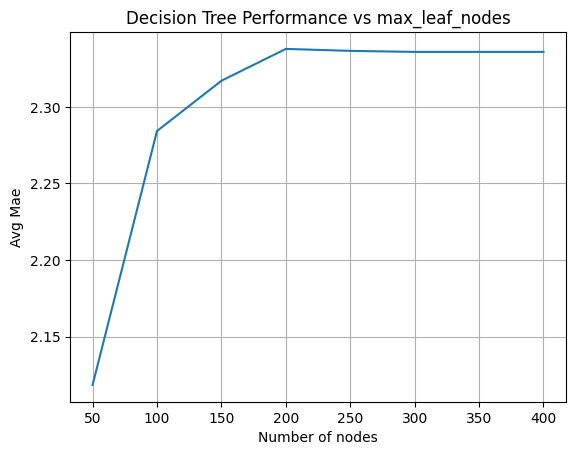

In [52]:
plt.plot(list(results.keys()),list(results.values()))
plt.xlabel("Number of nodes")
plt.ylabel("Avg Mae")
plt.title("Decision Tree Performance vs max_leaf_nodes")
plt.grid(True)
plt.show()

Using a Decision Tree Regressor with a preprocessing pipeline, I evaluated model performance using 5-fold cross-validation. Hyperparameter tuning showed that max_leaf_nodes = 50 achieved the lowest MAE (~2.118). Larger trees increased error due to overfitting, highlighting the importance of model complexity control.